# ALL BOOSTING - ML Interview Preparation

This notebook covers all major boosting algorithms and ensemble methods for machine learning interviews. Topics include AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost, and comparisons with Bagging and Stacking.

---

## Table of Contents
1. **Foundational Concepts**: AdaBoost, Gradient Boosting Intuition, Bias-Variance Perspective
2. **Bagging vs Boosting Comparison**
3. **Stacking Overview**
4. **How Boosting Reduces Bias**
5. **Overfitting in Boosting and Prevention**
6. **Key Hyperparameters for Boosting**
7. **GBM Implementations**: XGBoost, LightGBM, CatBoost (Deep Dives)
8. **Advanced Topics**: Sampling, Tree Growing, Categorical/Missing Data Handling
9. **Interview Section**: Top 10 Questions, Comparison Tables, Quick Reference

---

## AdaBoost (Adaptive Boosting) - Step-by-Step Algorithm

AdaBoost was one of the first successful boosting algorithms, proposed by Freund and Schapire (1996). It is the foundation upon which later boosting methods were built.

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>Core Idea:</strong> AdaBoost combines multiple <strong>weak learners</strong> (typically decision stumps -- trees with depth 1) into a single strong learner by sequentially focusing on the samples that previous learners got wrong.
</div>

### Step-by-Step Algorithm (Binary Classification)

**Step 1: Initialize sample weights**
- Assign equal weight to all N training samples: $w_i = \frac{1}{N}$ for $i = 1, 2, ..., N$

**Step 2: For each iteration t = 1, 2, ..., T:**

  a) **Train a weak learner** $h_t(x)$ on the weighted training data.

  b) **Compute the weighted error rate:**
$$\epsilon_t = \frac{\sum_{i=1}^{N} w_i \cdot \mathbb{1}[h_t(x_i) \neq y_i]}{\sum_{i=1}^{N} w_i}$$

  c) **Compute the learner's weight (vote):**
$$\alpha_t = \frac{1}{2} \ln\left(\frac{1 - \epsilon_t}{\epsilon_t}\right)$$
  - If $\epsilon_t < 0.5$, then $\alpha_t > 0$ (good learner gets positive weight)
  - If $\epsilon_t = 0.5$, then $\alpha_t = 0$ (random guessing, no contribution)

  d) **Update sample weights:**
$$w_i \leftarrow w_i \cdot \exp(-\alpha_t \cdot y_i \cdot h_t(x_i))$$
  - Misclassified samples get **higher weights** (so the next learner focuses on them)
  - Correctly classified samples get **lower weights**

  e) **Normalize weights** so they sum to 1.

**Step 3: Final prediction (majority vote):**
$$H(x) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t \cdot h_t(x)\right)$$

### Key Properties of AdaBoost
- **Loss Function**: Minimizes the exponential loss: $L = \sum_i \exp(-y_i \cdot F(x_i))$
- **Sensitive to outliers**: Because exponential loss penalizes misclassified samples heavily
- **No learning rate parameter** in the original formulation (unlike Gradient Boosting)
- **Weak learners**: Typically decision stumps, but can be any classifier slightly better than random

### Interview Tip: AdaBoost vs Gradient Boosting
| Aspect | AdaBoost | Gradient Boosting |
|--------|----------|-------------------|
| **How it corrects errors** | Re-weights misclassified samples | Fits new learner to residuals (gradients) |
| **Loss function** | Exponential loss (fixed) | Any differentiable loss function |
| **Flexibility** | Limited to exponential loss | Highly flexible (custom losses) |
| **Sensitivity to outliers** | High (exponential loss) | Depends on loss function chosen |
| **Base learners** | Typically stumps | Typically deeper trees (depth 3-8) |

---

## Gradient Boosting - Intuition and Algorithm

Gradient Boosting generalizes AdaBoost by allowing optimization of **any differentiable loss function**, not just exponential loss. Instead of re-weighting samples, it fits each new learner to the **negative gradient** (pseudo-residuals) of the loss function.

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>Core Intuition:</strong> Think of it as <strong>gradient descent in function space</strong>. At each step, we add a new function (tree) that moves our predictions in the direction that most reduces the loss. The "residuals" each tree fits are actually the negative gradients of the loss.
</div>

### Algorithm: Gradient Boosting for Regression (MSE Loss)

**Step 1: Initialize** with a constant prediction:
$$F_0(x) = \arg\min_{\gamma} \sum_{i=1}^{N} L(y_i, \gamma) = \bar{y} \quad \text{(mean of target)}$$

**Step 2: For each iteration m = 1, 2, ..., M:**

  a) **Compute pseudo-residuals** (negative gradient of loss w.r.t. current prediction):
$$r_{im} = -\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \bigg|_{F=F_{m-1}}$$
  For MSE loss: $r_{im} = y_i - F_{m-1}(x_i)$ (these are simply the residuals)

  b) **Fit a regression tree** $h_m(x)$ to the pseudo-residuals $\{r_{im}\}$

  c) **Compute the optimal step size** (learning rate for this tree):
$$\gamma_m = \arg\min_{\gamma} \sum_{i=1}^{N} L(y_i, F_{m-1}(x_i) + \gamma \cdot h_m(x_i))$$

  d) **Update the model:**
$$F_m(x) = F_{m-1}(x) + \eta \cdot \gamma_m \cdot h_m(x)$$
  where $\eta$ is the shrinkage/learning rate (typically 0.01 to 0.3)

**Step 3: Final model:** $F_M(x) = F_0(x) + \eta \sum_{m=1}^{M} \gamma_m \cdot h_m(x)$

### Why "Gradient" Boosting?

The key insight is that pseudo-residuals are the **negative gradients** of the loss function:

| Loss Function | Negative Gradient (Pseudo-residual) |
|--------------|--------------------------------------|
| MSE: $\frac{1}{2}(y - F)^2$ | $y - F$ (residual) |
| MAE: $\|y - F\|$ | $\text{sign}(y - F)$ |
| Log Loss: $-[y\log(p) + (1-y)\log(1-p)]$ | $y - p$ (where $p = \sigma(F)$) |

This means Gradient Boosting performs **gradient descent** -- but instead of updating parameters, it adds a new function (tree) at each step that points in the steepest descent direction.

### Interview Tip
> "Gradient Boosting is like a student who keeps getting feedback on their mistakes. After each test, the teacher highlights the errors, and the student specifically studies those topics. Over time, the student gets better by focusing on weaknesses, not strengths."

---

## Bagging vs Boosting - Detailed Comparison

Understanding the difference between Bagging and Boosting is one of the most commonly asked interview questions about ensemble methods.

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>Key Distinction:</strong> Bagging builds models <strong>independently in parallel</strong> to reduce variance. Boosting builds models <strong>sequentially</strong> where each model corrects the errors of the previous one, primarily to reduce bias.
</div>

| Aspect | Bagging | Boosting |
|--------|---------|----------|
| **Full Name** | Bootstrap Aggregating | (Adaptive/Gradient) Boosting |
| **Model Building** | Parallel (independent) | Sequential (dependent) |
| **Data Sampling** | Bootstrap samples (with replacement) | Weighted samples or residuals |
| **Model Weighting** | Equal weight to all models | Higher weight to better models |
| **Primary Goal** | Reduce **variance** | Reduce **bias** (and sometimes variance) |
| **Base Learners** | Strong learners (full trees) | Weak learners (shallow trees/stumps) |
| **Overfitting Risk** | Lower (averaging reduces variance) | Higher (sequential fitting can memorize noise) |
| **Sensitivity to Outliers** | Lower | Higher |
| **Parallelizable** | Yes (easily) | No (inherently sequential) |
| **Examples** | Random Forest, Bagged Trees | AdaBoost, Gradient Boosting, XGBoost |
| **Effect on Bias** | Approximately same as base learner | Reduces bias significantly |
| **Effect on Variance** | Reduces variance significantly | Can increase variance if overfit |

### How Bagging Works (Quick Recap)
1. Create B bootstrap samples (random sampling with replacement) from the training data
2. Train a separate model on each bootstrap sample **independently**
3. Aggregate predictions: **average** (regression) or **majority vote** (classification)
4. The key insight: averaging reduces variance by a factor of ~1/B if models are uncorrelated

### How Boosting Works (Quick Recap)
1. Start with a simple model (e.g., predict the mean)
2. Compute errors/residuals from the current model
3. Train a new model to correct those errors
4. Add the new model to the ensemble (with a learning rate)
5. Repeat -- each new model focuses on what the ensemble still gets wrong

### When to Choose Each
- **Use Bagging** when: your model has high variance (overfitting), data is noisy, you want stable predictions
- **Use Boosting** when: your model has high bias (underfitting), you need maximum predictive accuracy, data is relatively clean

---

## Bias-Variance Perspective on Ensemble Methods

Understanding how ensemble methods address the bias-variance tradeoff is critical for interviews.

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>Recall:</strong> Total Error = Bias<sup>2</sup> + Variance + Irreducible Noise
</div>

### Bias-Variance Decomposition by Method

| Method | Bias | Variance | How It Achieves This |
|--------|------|----------|---------------------|
| **Single Decision Tree** | Low | High | Deep trees fit training data well but are unstable |
| **Bagging (Random Forest)** | Low (same as base) | **Reduced** | Averaging many uncorrelated trees reduces variance |
| **Boosting (GBM/XGBoost)** | **Reduced** | Can increase | Sequential correction of errors reduces systematic bias |
| **Stacking** | **Reduced** | **Reduced** | Meta-learner learns optimal combination of diverse models |

### Why Bagging Reduces Variance
- If we have B independent models, each with variance $\sigma^2$, the variance of their average is $\sigma^2 / B$
- In practice, models from bootstrap samples are correlated (correlation $\rho$), so variance = $\rho \sigma^2 + \frac{(1-\rho)}{B} \sigma^2$
- Random Forest reduces $\rho$ further by using random feature subsets at each split
- **Key point**: Bagging does NOT reduce bias -- if individual trees are biased, the average is still biased

### Why Boosting Reduces Bias
- Each new tree specifically targets the **errors** (residuals) of the current ensemble
- The sequential correction gradually eliminates systematic prediction errors
- With enough iterations, boosting can approximate any function
- **Key point**: Boosting starts with high bias (weak learner) and iteratively reduces it
- **Risk**: Too many iterations can reduce bias to zero on training data (overfitting), which increases variance

### The Tradeoff in Practice
```
Boosting iterations:  Few ──────────────────────► Many
Bias:                 High ─────────────────────► Low (approaching 0)
Variance:             Low ──────────────────────► High (overfitting risk)
Training error:       High ─────────────────────► Very low (approaching 0)
Test error:           High ──► Optimal ──────────► Increases (overfitting)
```

### Interview Key Points
1. **Bagging** = variance reduction through averaging (bias stays the same)
2. **Boosting** = bias reduction through sequential learning (variance can increase)
3. **Learning rate** in boosting controls the bias-variance tradeoff: smaller rate = more trees needed but better generalization
4. **Early stopping** in boosting prevents variance from growing too large

---

## Stacking (Stacked Generalization) - Brief Overview

Stacking is another ensemble technique that is frequently asked about in interviews alongside Bagging and Boosting.

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>Core Idea:</strong> Train multiple diverse base models (Level 0), then train a <strong>meta-learner</strong> (Level 1) that learns how to best combine their predictions.
</div>

### How Stacking Works

```
Level 0 (Base Models):
  Model A (e.g., Random Forest)    ──► Prediction A
  Model B (e.g., XGBoost)          ──► Prediction B
  Model C (e.g., SVM)              ──► Prediction C
  Model D (e.g., KNN)              ──► Prediction D

Level 1 (Meta-Learner):
  [Prediction A, B, C, D] as features ──► Meta-Model (e.g., Logistic Regression) ──► Final Prediction
```

### Key Points for Interviews

1. **Diversity matters**: Base models should be as different as possible (different algorithms, different feature sets)
2. **Cross-validation is essential**: Base model predictions for the meta-learner must be generated using out-of-fold predictions to avoid data leakage
3. **Meta-learner is usually simple**: Often logistic regression or linear regression to avoid overfitting
4. **Stacking vs Blending**: Blending uses a holdout set instead of cross-validation for generating meta-features

### Stacking vs Bagging vs Boosting

| Aspect | Bagging | Boosting | Stacking |
|--------|---------|----------|----------|
| **Base models** | Same type (e.g., all trees) | Same type (sequential trees) | Different types (diverse) |
| **Training** | Parallel, independent | Sequential, dependent | Two levels: parallel base + meta |
| **Combination** | Average / majority vote | Weighted sum | Learned by meta-model |
| **Reduces** | Variance | Bias | Both bias and variance |
| **Complexity** | Low | Medium | High |
| **Risk of overfitting** | Low | Medium | High (needs careful CV) |

### When to Use Stacking
- Competition settings where every fraction of a percent matters
- When you have diverse models that make different types of errors
- When base models have complementary strengths
- **Not recommended** for production systems where simplicity and interpretability are priorities

---

## How Boosting Reduces Bias (Sequential Learning)

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>Interview Answer:</strong> Boosting reduces bias through <strong>sequential error correction</strong>. Each new model in the ensemble is specifically trained to fix the mistakes of the current ensemble, systematically eliminating prediction errors that a single model cannot capture.
</div>

### The Mechanism Step by Step

1. **Start with a weak model** (e.g., a decision stump with depth 1) -- this model has **high bias** because it is too simple to capture the true relationship
2. **Compute residuals**: Calculate what the current model gets wrong
3. **Fit a new model to the residuals**: This new model learns the **pattern in the errors** -- it captures relationships that the first model missed
4. **Add to ensemble**: The combined model now has **lower bias** because it captures more of the true signal
5. **Repeat**: Each successive model captures finer and finer patterns that previous models missed

### Concrete Example (Regression)

```
True function:      y = x^2 + sin(x) + noise

Iteration 1: Stump predicts y ~ 5.2 (constant)
  Residuals capture the quadratic and sinusoidal pattern

Iteration 2: Tree fits residuals, captures rough quadratic shape
  Remaining residuals capture the sinusoidal component

Iteration 3: Tree fits remaining residuals, captures sin(x) pattern
  Remaining residuals are mostly noise

... After M iterations: ensemble approximates x^2 + sin(x) well
```

### Why Weak Learners Are Preferred

- **Weak learners** (stumps, shallow trees) have high bias individually
- By combining many biased learners, each correcting the previous errors, the ensemble achieves low bias
- Using strong learners (deep trees) would risk overfitting at each step, accumulating variance
- The **learning rate** controls how much each weak learner contributes, preventing overcorrection

### Mathematical Perspective

After M iterations with learning rate $\eta$:
$$F_M(x) = F_0(x) + \eta \sum_{m=1}^{M} h_m(x)$$

- Each $h_m$ is trained to predict $r_m = y - F_{m-1}(x)$ (the current error)
- The bias of $F_M$ decreases because each term corrects the residual error
- With enough terms (large M) and small $\eta$, the model can approximate arbitrarily complex functions

---

## Overfitting in Boosting and How to Prevent It

Boosting is powerful but prone to overfitting, especially with many iterations or complex base learners. Understanding and preventing overfitting in boosting is a common interview topic.

### Why Boosting Can Overfit

1. **Too many iterations**: Each new tree reduces training error further; eventually the model starts fitting noise
2. **Deep trees**: Complex base learners can memorize training patterns instead of learning general ones
3. **High learning rate**: Large steps can cause the model to oscillate and overfit quickly
4. **No regularization**: Without constraints, trees can grow arbitrarily complex
5. **Small datasets**: With limited data, boosting models can easily memorize training examples

### Techniques to Prevent Overfitting in Boosting

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>The 7 Key Strategies:</strong>
</div>

| Strategy | Parameter(s) | How It Helps |
|----------|-------------|--------------|
| **1. Lower learning rate** | `learning_rate` / `eta` (0.01-0.1) | Smaller steps = smoother learning = better generalization |
| **2. Early stopping** | `early_stopping_rounds` | Stop training when validation score stops improving |
| **3. Limit tree depth** | `max_depth` (3-7) | Shallower trees = simpler base learners = less overfitting |
| **4. Row subsampling** | `subsample` (0.5-0.8) | Use random subset of data per tree (like bagging within boosting) |
| **5. Column subsampling** | `colsample_bytree` (0.5-0.8) | Use random subset of features per tree (like Random Forest) |
| **6. L1/L2 regularization** | `alpha`, `lambda` | Penalize complex leaf weights |
| **7. Min child weight** | `min_child_weight` | Prevent splits on nodes with too few samples |

### Recommended Tuning Strategy (Interview Answer)

```
Step 1: Set learning_rate = 0.1, n_estimators = 1000, use early_stopping
Step 2: Tune max_depth (try 3, 5, 7) and min_child_weight
Step 3: Tune subsample and colsample_bytree (try 0.6, 0.8, 1.0)
Step 4: Tune regularization (gamma, alpha, lambda)
Step 5: Lower learning_rate to 0.01-0.05, increase n_estimators, re-run with early_stopping
```

### Key Hyperparameters Summary for Boosting

| Parameter | Typical Range | Effect on Overfitting |
|-----------|--------------|----------------------|
| `n_estimators` | 100-10000 | More = higher risk (use early stopping) |
| `learning_rate` | 0.01-0.3 | Lower = safer but needs more trees |
| `max_depth` | 3-8 | Lower = safer |
| `subsample` | 0.5-1.0 | Lower = safer (introduces randomness) |
| `colsample_bytree` | 0.5-1.0 | Lower = safer (reduces feature correlation) |
| `min_child_weight` | 1-10 | Higher = safer (prevents small leaf nodes) |
| `gamma` | 0-5 | Higher = more conservative splits |
| `reg_alpha` (L1) | 0-1 | Higher = more sparse model |
| `reg_lambda` (L2) | 1-10 | Higher = smoother leaf weights |


---

## Gradient Boosting Machines: XGBoost, LightGBM, CatBoost

All three algorithms (XGBoost, LightGBM, CatBoost) are advanced, highly optimized implementations of **Gradient Boosting Machines (GBMs)**. They are popular choices for structured data problems due to their high performance.

### Gradient Boosting Machines (GBM) - The Foundation

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>Core Concept:</strong> GBM builds an ensemble of decision trees <strong>sequentially</strong>. Each new tree is trained to correct the errors (specifically, the pseudo-residuals based on the negative gradient of the loss function) made by the ensemble of previously grown trees.
</div>

*   Starts with an initial prediction (e.g., the mean of the target variable).
*   Iteratively adds trees:
    *   Calculate the errors (residuals) of the current ensemble.
    *   Train a new tree to predict these errors.
    *   Add this new tree's prediction (scaled by a learning rate) to the ensemble's prediction.
*   **Challenge:** Standard GBM implementations can be slow and prone to overfitting without careful tuning.

---

### 1. XGBoost (Extreme Gradient Boosting)

Developed to improve upon standard GBMs by focusing on computational speed, scalability, and model performance through better regularization.

<blockquote style="border-left: 5px solid #61dafb; padding-left: 10px; color: #ffffff; background-color: #333; padding: 10px;">
    <strong>Core Idea:</strong> Enhance GBM with improved <strong>regularization</strong> techniques and optimized computation for speed and accuracy.
</blockquote>

**Key Features & Innovations:**

*   **Regularization:** Introduces **L1 (Lasso)** and **L2 (Ridge)** regularization terms to the loss function. This penalizes complex models (e.g., trees with large leaf weights), helping significantly to prevent overfitting.
*   **Second-Order Taylor Expansion:** Uses both the first and second derivatives (**gradient and Hessian**) of the loss function for optimization. This provides more information about the loss function's curvature, often leading to more accurate tree splits compared to standard GBM (which typically uses only the gradient).
*   **Handling Missing Values:** Has a built-in routine. During split finding, it learns a **default direction** for missing values in each node by evaluating which direction (left or right split) maximizes the gain.
*   **Optimized Split Finding:**
    *   **Approximate Greedy Algorithm:** For large datasets, proposes candidate splits only at percentiles of feature distributions (using techniques like Weighted Quantile Sketch) instead of evaluating every single possible split point.
    *   **Sparsity-Aware Split Finding:** Efficiently handles missing values, zero entries, etc., during split calculations without needing dense representations.
*   **System Optimizations:**
    *   **Parallelization:** Tree construction can be parallelized at the node level using a block structure for data layout.
    *   **Cache Awareness:** Algorithm designed to make efficient use of CPU cache.
    *   **Out-of-Core Computation:** Can process datasets larger than the available RAM by utilizing disk space.

---

### 2. LightGBM (Light Gradient Boosting Machine)

Developed by Microsoft, LightGBM focuses primarily on being a **faster** and more **memory-efficient** implementation of gradient boosting, especially effective on large datasets.

<blockquote style="border-left: 5px solid #61dafb; padding-left: 10px; color: #ffffff; background-color: #333; padding: 10px;">
    <strong>Core Idea:</strong> Achieve significant speed-ups over other GBM implementations using novel sampling techniques and an efficient tree growth strategy.
</blockquote>

**Key Features & Innovations:**

*   **Leaf-wise Tree Growth:** Grows trees by splitting the leaf that yields the largest reduction in loss (highest delta loss), rather than growing level-by-level. This often converges faster and can lead to better accuracy.
    *   *Caution:* Can lead to overfitting on smaller datasets if depth/leaf constraints (`max_depth`, `num_leaves`) aren't carefully managed.
*   **Histogram-Based Algorithm:** `Buckets continuous features into discrete bins `(histograms). Split finding is then performed on these bins instead of sorted continuous values, drastically reducing computational cost, especially for large datasets. `(XGBoost also offers this, but LightGBM's implementation is often highly efficient).`
*   **Gradient-based One-Side Sampling (GOSS):** A sampling method to speed up training. It keeps all instances with large gradients (those that are poorly predicted) and performs random sampling on instances with small gradients. This focuses computation on the "harder" examples without completely ignoring the "easier" ones.
*   **Exclusive Feature Bundling (EFB):** Bundles mutually exclusive features (those that `rarely take non-zero values simultaneously, common in sparse data like one-hot encodings) into single features.` This reduces the effective feature dimensionality, speeding up training.


### 3. CatBoost (Categorical Boosting)

Developed by Yandex, CatBoost's primary innovations lie in its sophisticated, built-in handling of **categorical features** and a novel boosting scheme (**Ordered Boosting**) to combat prediction shift (target leakage).

<blockquote style="border-left: 5px solid #61dafb; padding-left: 10px; color: #ffffff; background-color: #333; padding: 10px;">
    <strong>Core Idea:</strong> Natively handle categorical features effectively and improve model robustness against overfitting using Ordered Boosting and symmetric trees.
</blockquote>

**Key Features & Innovations:**

*   **Superior Handling of Categorical Features:** This is CatBoost's standout feature.
    *   **Ordered Target Statistics (Ordered TS):** A robust way to encode categorical features numerically. To avoid target leakage, the target statistic (e.g., average target value for a category) for a given sample is calculated using only the target values of samples that appeared `*before*` it in a random permutation of the data.
    *   **One-Hot Encoding:** Automatically applies one-hot encoding for low-cardinality categorical features (controlled by `one_hot_max_size`).
    *   **Feature Combinations:** Can automatically generate and include combinations of categorical features.
*   **Ordered Boosting:** A modification of the standard gradient boosting procedure. It uses multiple random permutations of the dataset. When calculating residuals for a sample, `it uses a model trained only on the samples preceding it in that specific permutation. `T `his prevents target leakage in gradient estimation and leads to less biased residuals, improving model generalization.`
*   **Symmetric Trees (Oblivious Trees):** Uses decision trees `where the *same splitting criterion* (feature and value) is applied across an entire level of the tree`. This results in balanced trees, acts as a form of regularization helping to prevent overfitting, and significantly speeds up prediction time (inference).

###  Key Differences:

| Feature               | XGBoost                                  | LightGBM                                 | CatBoost                                        |
| :-------------------- | :--------------------------------------- | :--------------------------------------- | :---------------------------------------------- |
| **Main Focus**        | Regularization, Accuracy, System Opt.    | Speed, Efficiency, Memory Usage          | Categorical Features, Robustness, Ease of Use |
| **Tree Growth**       | Level-wise (or Leaf-wise option)         | Leaf-wise (default)                      | Symmetric/Oblivious (Level-wise)              |
| **Categorical Data**  | Requires preprocessing (e.g., one-hot)   | Requires preprocessing (int encode rec.) | **Native handling (Ordered TS, auto OHE)**      |
| **Missing Values**    | Built-in (Sparsity-aware)                | Built-in (Handles NaN)                   | Built-in (Treats as category or min/max)    |
| **Regularization**    | **L1/L2 explicitly added**               | L1/L2 available                          | **Built-in (via Ordered Boosting, tree struct)**|
| **Speed**             | Fast (Parallel, Approx. splits)          | **Very Fast (GOSS, EFB, Histograms)**      | Fast (esp. prediction), Training can vary     |
| **Key Innovations**   | Regularization, 2nd Order Grads, Sparsity | Leaf-wise growth, GOSS, EFB, Histograms  | **Ordered Boosting, Ordered TS, Symmetric Trees** |
| **Overfitting Ctrl**  | Good control via Regularization          | Tune `num_leaves`, `max_depth` carefully | **Generally robust (Ordered Boosting, Sym Trees)**|

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>For Interviews:</strong> Be ready to articulate the <strong>core idea</strong> behind each algorithm and highlight their <strong>key differentiating features</strong> (e.g., how CatBoost handles categoricals, why LightGBM is fast, XGBoost's regularization). Explain <em>why</em> a specific feature helps achieve the algorithm's goals.
</div>

---

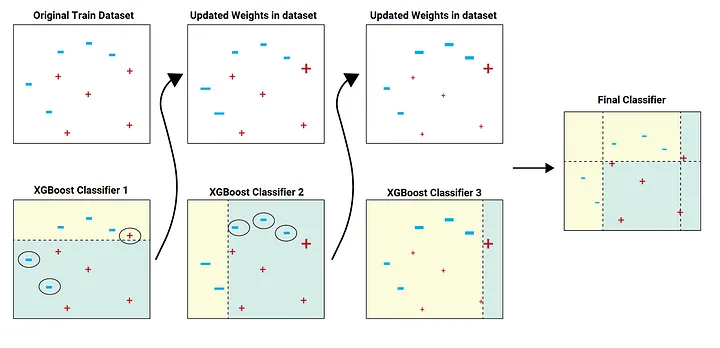


## 1. What is _XGBoost_ and why is it considered an effective _machine learning algorithm_?

**XGBoost**, short for e**X**treme **G**radient **Boosting**, is a powerful and commonly used algorithm, highly renowned for its accuracy and speed in predictive modeling across various domains like **industry competitions**, finance, insurance, and healthcare.

### How XGBoost Works

XGBoost builds a series of trees to make predictions, and each tree corrects errors made by the previous ones. The algorithm minimizes a **loss function**, often the mean squared error for regression tasks and the log loss for classification tasks.

The ensemble of trees in XGBoost is more flexible and capable than traditional gradient boosting due to:

- **Regularization**: This controls model complexity to prevent overfitting, contributing to XGBoost's robustness.
- **Shrinkage**: Each tree's contribution is modulated, reducing the impact of outliers.
- **Cross-Validation**: XGBoost internally performs cross-validation tasks to fine-tune hyperparameters, such as the number of trees, boosting round, etc.

### Key Features of XGBoost

1. **Parallel Processing**: The advanced model construction techniques, including parallel and distributed computing, deliver high efficiency.
  
2. **Feature Importance**: XGBoost offers insightful mechanisms to `rank and select features`, empowering better decision-making.

3. **Handling Missing Data**: It can manage missing data in both the `training and evaluation phases`, simplifying real-world data scenarios.

4. **Flexibility**: XGBoost effectively addresses diverse situations like classification, regression, and ranking.

5. **GPU Support**: It optionally taps into GPU's immense parallel processing capabilities, further expediting computations.



### Python: Code Example for XGBoost Model

Here is the Python code:

``` python
import xgboost as xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load Boston dataset
boston = load_boston()
X, y = boston.data, boston.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build XGBoost model
xg_reg = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1, max_depth = 5, alpha = 10, n_estimators = 10)
xg_reg.fit(X_train, y_train)

# Predict and evaluate the model
preds = xg_reg.predict(X_test)
rmse = mean_squared_error(y_test, preds, squared=False)
print("RMSE: %f" % (rmse))
```
<br>




## 3. How does _XGBoost_ handle missing or null values in the _dataset_?

**XGBoost** has built-in mechanisms to effectively handle missing or null values. This powerful feature makes it ideal for datasets with incomplete information.

### Sparsity-Aware Split Finding

XGBoost automatically detects **if a feature is missing** and learns the best direction to move in the tree to minimize loss. The algorithm makes this decision during split finding and tree building. If a missing value does not help improve the loss, the path leading to this missing value is minimized by setting the associated weights to 0.

### Weight Adjustments

> The algorithm utilizes **three-to-five splits**, depending on the best solution. If a feature is missing, weights of leaf nodes with missing values are adjusted.

### Visual Representation: Handling Missing Data

![Handling Missing Data](https://firebasestorage.googleapis.com/v0/b/dev-stack-app.appspot.com/o/xgboost%2Fhandling-missing-data-through-XGBoost-min.png?alt=media&token=eefba964-c5e7-486d-ac23-0101529cb735)

### Code Example: Utilizing `xgboost.DMatrix`

In the Python code provided, `xgboost.DMatrix` is used for more fine-grained control.

```python
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Creating a sample dataset with missing values
data = {
    'feature1': [1, 2, np.nan, 4, 5],
    'label': [0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

# Assigning missing values to a column
df.loc[df['feature1'].isnull(), 'feature1'] = -999

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(df['feature1'], df['label'], test_size=0.2)

# Converting the dataset to 'DMatrix'
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Defining model parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss'
}

# Training the model
model = xgb.train(params, dtrain, num_boost_round=10)

# Making predictions
preds = model.predict(dtest)
```

Here, we're allowing the model to consider `-999` as a representation for missing data.
<br>



## 4. What is meant by _'regularization'_ in _XGBoost_ and how does it help in preventing _overfitting_?

**Regularization** in XGBoost is a technique used to prevent overfitting by adding a penalty term to the model's **objective function**. This term discourages overly complex models and is there to ensure that the tree does rely solely on the most prominent features.

### Regularization Parameters in XGBoost

XGBoost offers several hyperparameters for controlling the regularization strength:

1. **L1 Regularization (```alpha``` or ```reg_alpha```)**: Encourages sparsity in feature selection by adding the sum of absolute values of the weights to the cost function.

$$
J = J_0 + \alpha \sum_{i=1}^n |w_i|
$$

2. **L2 Regularization (```lambda``` or ```reg_lambda``` or ```reg_weight```)**: Also known as weight decay, it adds the sum of squares of the weights to the cost function.

$$
J = J_0 + \lambda \frac{1}{2} \sum_{i=1}^n w_i^2
$$
   
3. **Max Depth (```max_depth```)**: Another form of regularization, it limits the maximum depth a tree can grow to.

4. **Minimum Child Weight (```min_child_weight```)**: This parameter also assists in `controlling leaf node size`, thereby preventing splitting in specific cases when a leaf is too weighted.
<br>


## 6. Explain the concept of _gradient boosting_. How does it work in the context of _XGBoost_?

**Gradient Boosted Models** (GBMs) are ensemble methods that build models in a **forward stepwise manner**, using decision trees as base learners. The algorithm can be computationally intensive, making it a somewhat challenging learning model. However, through its improved accuracy and speed, along with advanced regularization techniques, it's still a popular option.

**Extreme Gradient Boosting (XGBoost)** is a variant of this algorithm optimized for both speed and performance, offering several unique features.

### Key Concepts and Methodology

- **Sequential Training**: XGBoost uses an approach called **boosting**, where each new model targets errors from the prior ones, creating an additive sequence of predictors.

- **Gradient Optimization**: The algorithm minimizes a predefined loss function by following the **steepest descent** in the model's parameter space.

- **Principle Components**: Boosting iteratively fits small, simple models to the residuals of the preceding model, refining these fits over time and, in turn, improving the overall prediction.

- **Shrinkage (Learning Rate)**: Learning rate, typically small (e.g., 0.1), scales the contribution of each tree. Lower learning rates yield better accuracy at the cost of slower convergence.

- **Tree Pruning**: The trees can be pruned of their most irrelevant subtrees, which both boosts efficiency and limits overfitting.

- **Regularization**: Both L1 and L2 regularization are used, reducing the risk of overfitting.

- **Feature Importance**: The model calculates the importance of each feature, aiding in the selection process.

- **Support for Missing Data**: The models natively handle missing data.

- **Cross-Validation**: A built-in function for cross-validation helps choose the optimal number of trees.



 XGBoost integrates several other innovations that help it work faster and more effectively:

XGBoost’s power comes from a combination of these algorithmic and engineering innovations. Out-of-the-box, it:

-   Uses **approximate split finding** (via techniques like the Weighted Quantile Sketch and histogram-based methods) to reduce computational cost.
    
-   Optimizes with both **first-order and second-order derivatives** for accurate, stable training.
    
-   Incorporates **regularization** to control overfitting.
    
-   Leverages **hardware optimizations** (parallel processing, GPU support, cache optimization, out-of-core computation) for speed.
    
-   Offers advanced features like **DART** and **monotonic constraints** to further enhance performance and incorporate domain knowledge.
----------

### 1. **Histogram-based (Approximate) Split Finding**

-   **What It Is:**  
    Instead of evaluating every possible split on continuous features, XGBoost groups feature values into a fixed number of discrete bins (histograms). This binning approach dramatically reduces the number of split candidates.
    
-   **How It Works:**  
    The algorithm uses techniques like the **Weighted Quantile Sketch** to summarize feature distributions even when instance weights are involved. Once binned, `the best split is determined by scanning over these bins`, rather than over all unique values.
    
-   **Why It Helps:**  
    It reduces computation time with a small trade-off in split precision—ideal for large datasets.
    
```
tree_method='hist'  # enables histogram-based algorithm
```


----------

### 2. **Sparsity-aware Split Finding**

-   **What It Is:**  
    XGBoost is designed to efficiently handle sparse data (data with many missing or zero values).
    
-   **How It Works:**  
    During tree construction, it automatically learns the best “default direction” (left or right in the tree) to send missing values. This means you don’t have to manually impute missing data, and the algorithm can still make smart split decisions.
    
-   **Why It Helps:**  
    This ensures that models are robust when dealing with incomplete datasets, which is common in real-world scenarios.
    

----------

### 3. **Second-order Gradient Optimization**

-   **What It Is:**  
    XGBoost optimizes its objective function using both first-order (gradient) and second-order (Hessian) information.
    
-   **How It Works:**  
    When expanding a tree, the algorithm approximates the loss function with a second-order Taylor expansion. This allows it to make more precise adjustments at each iteration by considering `how the loss changes (curvature) rather than just the slope`.
    
-   **Why It Helps:**  
    This method leads to more accurate and stable training updates, often resulting in faster convergence and improved predictive performance.
    

----------

### 4. **Integrated Regularization**

-   **What It Is:**  
    Unlike traditional GBMs, XGBoost incorporates regularization terms directly into the loss function.
    
-   **How It Works:**  
    The regularization is applied in the form of:
    
    -   **L1 Regularization (α):** Encourages sparsity by penalizing the absolute value of leaf weights.
        
    -   **L2 Regularization (λ):** Penalizes the square of leaf weights to reduce model complexity.
        
    -   **γ (gamma):** A threshold for the minimum loss reduction needed to make a split.
        
    
    The modified objective becomes:
    
    Objective= $$ ∑il(yi,y^i)+∑k(γT+12λ∑jwj2+α∑j∣wj∣)\text{Objective} = \sum_i l(y_i, \hat{y}_i) + \sum_k \left(\gamma T + \frac{1}{2} \lambda \sum_j w_j^2 + \alpha \sum_j |w_j|\right) $$
-   **Why It Helps:**  
    These regularization terms help prevent overfitting by controlling the complexity of the model, making it more generalizable.
    

----------

### 5. **Column Block Structure & Cache Optimization**

-   **What It Is:**  
    XGBoost organizes data in a columnar (block) structure, which is optimal for accessing features.
    
-   **How It Works:**  
    This structure aligns well with CPU cache memory, meaning that when the algorithm is scanning through feature values to find splits, it benefits from fast memory access.
    
-   **Why It Helps:**  
    Better cache utilization leads to faster computations, especially when handling large datasets.
    

----------

### 6. **Out-of-Core (Disk-based) Computation**

-   **What It Is:**  
    For datasets that do not fit entirely into memory, XGBoost supports out-of-core computation.
    
-   **How It Works:**  
    It partitions data and uses disk space as an extension of RAM, processing data in chunks while still maintaining efficiency.
    
-   **Why It Helps:**  
    This makes XGBoost scalable to very large datasets that exceed the available memory.
    

----------

### 7. **Parallel Processing**

-   **What It Is:**  
    XGBoost takes advantage of multi-threading to speed up training.
    
-   **How It Works:**  
    Although the trees are built sequentially (each tree correcting the previous one), the algorithm `parallelizes the process of finding the best split at each node across all features`. This means that multiple CPU cores work together to evaluate candidate splits simultaneously.
    
-   **Why It Helps:**  
    It drastically reduces training time by fully utilizing modern multi-core CPUs.
    

----------

### 8. **DART (Dropouts meet Multiple Additive Regression Trees)**

-   **What It Is:**  
    DART is a variant of XGBoost that introduces dropout techniques—similar to dropout in neural networks—into the boosting process.
    
-   **How It Works:**  
    During training, a random subset of trees is dropped when updating the model, which forces the model to be more robust by not relying too heavily on any single tree.
    
-   **Why It Helps:**  
    This can reduce overfitting and improve model generalization, especially in noisy datasets.
    

----------

### 9. **Monotonicity Constraints**

-   **What It Is:**  
    This feature allows you to enforce a predetermined relationship between features and the prediction. For example, you might require that an increase in a feature (like income) should not lead to a decrease in the predicted probability of loan approval.
    
-   **How It Works:**  
    You specify constraints (e.g., `1` for increasing, `-1` for decreasing, `0` for no constraint) for each feature. During tree construction, XGBoost only considers splits that obey these constraints.
    
-   **Why It Helps:**  
    It enables the integration of domain knowledge into the model, making predictions more interpretable and aligned with business logic.
    








## 7. What are the _loss functions_ used in _XGBoost_ for _regression_ and _classification_ problems?

**XGBoost** offers various performance measure approaches, known as **loss functions**, to optimize model training for regression and classification tasks.

### Regression Loss Functions

1. **Squared Loss (L2 Loss)**: Primarily used for mean target estimation in regression tasks. It measures the difference between predicted and actual values, summing up the squared differences across all instances. L2 regularization adds a penalty term based on the sum of squared model weights.

![equation](https://firebasestorage.googleapis.com/v0/b/dev-stack-app.appspot.com/o/xgboost%2Fxgboost7_1.png?alt=media&token=c0bb1673-d0bc-4c80-bdc1-8d830d0b1c6e)

2. **Absolute Loss (L1 Loss)**: This loss function uses the absolute difference between the predicted and actual values instead of squares.

![equation](https://firebasestorage.googleapis.com/v0/b/dev-stack-app.appspot.com/o/xgboost%2Fxgboost7_2.png?alt=media&token=b99407c5-5f97-4257-944f-c55887064958)

3. **Huber Loss**: A combination of L1 and L2 Loss that is less sensitive to outliers. It switches to L1 Loss if the absolute difference is above a $\delta$ threshold.

   ```
   def huber_loss(y_true, y_predicted, delta):
       error = y_true - y_predicted
       return np.where(np.abs(error) < delta, 0.5 * error**2, delta * (np.abs(error) - 0.5 * delta))
   ```

### Classification Loss Functions

1. **Logistic Loss**: Commonly employed in binary classification problems. It calculates the likelihood of the predicted class, converting it to a probability with a sigmoid function.

$$
L = -\sum_{i=1}^{n} \left[ y_i \log p_i + (1 - y_i) \log (1 - p_i) \right]
$$

2. **Softmax Loss**: Generally used for multi-class classification tasks. It calculates a probability distribution for each class and maximizes the likelihood across all classes.

$$
L = -\sum_{i=1}^{n} \sum_{j=1}^{k} y_{ij} \log(p_{ij})
$$

3. **Adaptive Log Loss (ALogLoss):**
   Introduced in XGBoost, this loss function provides a balance between speed and accuracy. It's derived by approximating the Poisson likelihood.

<br>


## 8. How does _XGBoost_ use _tree pruning_ and why is it important?

### How XGBoost Uses Tree Pruning

**1. Pruning During Tree Construction:**

-   **Pre-Pruning (Early Stopping on Splits):**  
    XGBoost allows you to set parameters such as `max_depth`, `min_child_weight`, and `gamma` to control tree growth.
    
    -   **`max_depth`:** Sets the maximum depth of the trees. This directly limits how many splits a tree can have, preventing it from growing too complex.
        
    -   **`min_child_weight`:** Specifies the `minimum sum of instance weights1 needed in a child node. If a split does not meet this threshold, it is not pursued, `which effectively prunes weak branches` before they develop further.
        
    -   **`gamma`:** Represents the `minimum loss reduction` required to make a split. If a candidate split does not reduce the loss by at least `gamma`, that split is not made. This acts as a gatekeeper that prunes branches that offer little to no gain.
        
-   **Post-Pruning (Regularization-Based Pruning):**  
    After constructing a tree, XGBoost evaluates `the contribution of each branch (or node) to the overall predictive performance`. Branches that do not provide sufficient gain (i.e., the reduction in the loss function is below a threshold) are pruned away. `This backward pruning proces`—akin to cost-complexity pruning in traditional decision trees—ensures that the final tree is not overly complex and remains robust against overfitting.
    

----------

### Why Tree Pruning Is Important in XGBoost

1.  **Prevention of Overfitting:**  
    Overfitting occurs when a model captures noise or spurious patterns in the training data. By pruning branches that do not contribute significantly to reducing the loss, XGBoost keeps the model simpler and more generalizable. This is especially crucial when dealing with noisy or limited datasets.
    
2.  **Improved Computational Efficiency:**  
    
    
3.  **Enhanced Interpretability:**  
    Pruned trees are typically shallower and less complex, making it easier to understand how the model is making its decisions. This can be valuable when you need to explain model behavior to stakeholders or debug issues in model performance.
    
4.  **Regularization Through Pruning:**  
    Pruning is a form of regularization. By removing branches that do not offer significant improvement, the model avoids becoming overly complex and remains less prone to capturing noise.` This integrated regularization (using L1/L2 penalties and split constraints) ensures` `that the learned trees focus on the most informative splits.`
    

----------

### Code Example: Regularize Tree Depth with XGBoost

Here is the Python code:

```python
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load some example data
data = load_breast_cancer()
X = data.data
y = data.target

# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating the XGBoost model with regularized tree depth
xgb_model = XGBClassifier(max_depth=3, learning_rate=0.1, n_estimators=100)
xgb_model.fit(X_train, y_train)

# Making predictions
y_pred = xgb_model.predict(X_test)
```

In this example, `max_depth=3` is used to control the tree depth, which can help prevent overfitting and improve computational efficiency.
<br>




## 9. Describe the role of _shrinkage (learning rate)_ in _XGBoost_.

**Learning Rate**, also known as **shrinkage**, refers to a technique in XGBoost that influences the contribution of each tree to the final prediction. This mechanism is designed to improve the balance between model complexity and learning speed.

### Mechanism

- Each prediction step in an XGBoost model is the sum of predictions from all trees. The learning rate scales the contribution of each tree, allowing the model to require fewer trees during training.

![equation](https://firebasestorage.googleapis.com/v0/b/dev-stack-app.appspot.com/o/xgboost%2Fxgboost9.png?alt=media&token=5f39c014-dca3-49d9-831f-89b63532453c)

- Post-multiplication, the shrinkage factor reduces the influence of each tree's prediction in the final result.

### Core Functions

- **Regularization**: Learning Rate affects the strength of the regularization methods like L1 and L2. With a smaller learning rate, the model is trained for a longer duration, potentially intensifying the impact of regularization.
    
- **Effect on Overfitting**: A lower rate implies a lower learning speed, which can mitigate overfitting.

- **Speed and Convergence**: A higher learning rate accelerates training but can result in oscillations around the local minimum. Meanwhile, a lower learning rate leads to steadier convergence, suitable for reaching the global minimum.

### Practical Tuning Tips

- **Grid Search**: Allocate specific learning rate ranges in grid searches to determine the optimal value.

- **Cross-Validation**: Validate learning rates along with other hyperparameters using cross-validation to guarantee robust model performance.
<br>



## 10. What are the core _parameters_ in _XGBoost_ that you often consider tuning?

**XGBoost** also offers various hyperparameters for performance optimization. Let's explore the core ones often tuned during **cross-validation** and grid search.

### Core Parameters

- **N-estimators**: The number of boosting rounds. Higher values can lead to overfitting, so it's crucial for model stability.
- **Max depth**: Determines the maximum depth of each tree for better control over model complexity. Deeper trees can lead to overfitting.
- **Subsample**: Represents the fraction of data to be randomly sampled for each boosting round, helping to prevent overfitting.
- **Learning rate (eta)**: Scales the contribution of each tree, offering both control over speed and potential for better accuracy.

### Regularization Parameters

- **Gamma (min_split_loss)**: Specifies the minimum loss reduction required to make a further partition.
- **Alpha & Lambda**: Control the L1 and L2 regularization terms, aiding in case of highly-correlated features.

### Cross-Validation and Scoring

- **Objective**: Defines the loss function to be optimized, such as 'reg:squarederror' for regression and 'binary:logistic' for binary classification. There are various objectives catering to different problems.
- **Evaluation Metric**: Defines the metric to be used for cross-validation and model evaluation, such as 'rmse' for regression and 'auc' for binary classification.

### Specialized Parameters

- **Max delta step**: Useful for those employing Logistic Regression with imbalanced classes.
- **Tree method**: `For specifying the tree construction method like 'hist' for approximate tree method.`
- **Scale Pos Weight**: `For imbalanced class problems.`
- **Silent**: Used for suppressing all messages.
- **Seed**: Controls the randomness.

### Model Training Parameters

- **Learning Rate (eta)**: Scales the contribution of each tree, offering both control over speed and potential for better accuracy.
- **gamma (alias: min_split_loss)**: Specifies the minimum loss reduction required to make a further partition.
- **colsample_bytree**: The fraction of features to select from at each level of the tree.
- **lambda (alias: reg_lambda)**: L2 regularization term on weights.
- **alpha (alias: reg_alpha)**: L1 regularization term on weights.

### Device and Storage Parameters

- Determining the memory constraints and speeding up training.
- CPU/GPU selection.

### Advanced Parameters

- **Dart**: Helps avoid overfitting through aggressive dropout.
- **Colsample_bynode**: Controls the fraction of features to be used for each node split in a specific level.
- **Categorical Features**: Incorporates categorical features in XGBoost models.

### APIs for Distributed Computing

- **process_type** and **updater**.

#### Code Example: Parameter Tuning

Here is the Python code:

```python
import xgboost as xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error

# Load Boston housing data
boston = load_boston()
X, y = boston.data, boston.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameters for grid search
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001]
}

# Instantiate and fit the model with cross-validation and grid search
xg_reg = xgb.XGBRegressor(eval_metric='rmse')
grid_search = GridSearchCV(estimator=xg_reg, param_grid=params, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)

# Get best parameters and evaluate on test set
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("Best parameters from grid search:", best_params)
print("RMSE on test set:", rmse)
```
<br>



## 11. Explain the importance of the _'max_depth'_ parameter in _XGBoost_.

In XGBoost, the **'max_depth'** parameter sets the maximum depth of each tree, corresponding to the number of nodes from the root to the farthest leaf. Restricting this depth enhances performance across a variety of **regression** and **classification** tasks.

### Benefits of Setting 'max_depth'

- **Prevents Overfitting**: A `shallow tree can generalize better` on unseen data, reducing overfitting risks.
- **Computational Efficiency**: By limiting the tree's depth, XGBoost conserves memory use and computational resources. This efficiency is vital in handling large datasets and during real-time prediction.

### Rule of Thumb

- For a **binary classification** task with many features, a 'max_depth' of `2 to 8 `is often optimal.
- Utilize default values whenever possible. XGBoost's built-in mechanisms typically lead to effective, robust models with minimal manual parameter tuning.
<br>

## 12. Discuss how to manage the trade-off between _learning rate_ and _n_estimators_ in _XGBoost_.

Balancing the **learning rate** (or shrinkage) and the number of **boosting stages** (or trees) in **XGBoost** is critical for optimizing both training duration and predictive accuracy.

### The Trade-Off

- **Learning Rate**: Affects the influence of each tree on the final outcome. `Smaller rates necessitate higher tree counts`, but can lead to better generalization due to more gradual model updates.

- **Number of Trees**: Correlates with model complexity and training time. `Fewer trees may underfit`, while too many can overfit and slow down training.

### Searching the Optimal Space

- **Analytical Audit**: Validate prior choices using learning curves, feature importance, and cross-validation mean square error.

- **Grid Search**: Exhaustively try all combinations within bounded intervals for both parameters.

### Visualizing the Relationship

When executing the grid search, plotting both the learning rate and number of estimators against the chosen performance metric provides a **3D landscape view**.

### The Code Example

Here is the Python code:

```python
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_boston, load_digits

# Load datasets
boston = load_boston()
digits = load_digits()

# Parameter grid
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2, 0.3],
    'n_estimators': [50, 100, 150, 200],
}

# Grid search
clf_boston = GridSearchCV(xgb.XGBRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
clf_digits = GridSearchCV(xgb.XGBClassifier(), param_grid, cv=5)

# Fit the models
clf_boston.fit(boston.data, boston.target)
clf_digits.fit(digits.data, digits.target)

# Best parameters
print('Best parameters for Boston:', clf_boston.best_params_)
print('Best parameters for Digits:', clf_digits.best_params_)
```
<br>

## 13. What is _early stopping_ in _XGBoost_ and how can it be implemented?

**Early Stopping** in XGBoost helps prevent overfitting and makes training more efficient by stopping iterations when performance on a validation dataset doesn't improve. This is achieved by monitoring a metric `like AUC, logloss, or error`.

### Implementation

1. **Define Parameters**: Set the parameters for early stopping:

   - `eval_metric`: Metric to evaluate on the validation set.
   - `eval_set`: Data to use for evaluation. This should be a list of tuples, with each tuple in the format `(X, y)`. You can have multiple tuples to evaluate on multiple datasets.
   - `early_stopping_rounds`: The number of rounds with no improvement after which training will stop.

2. **Training XGBoost Model**: Train the XGBoost model with the defined parameters using `xgb.train(...)` or `xgb.XGBClassifier.fit(...)` and `xgb.XGBClassifier.predict(...)`.

   ```python
   from xgboost import XGBClassifier
   model = XGBClassifier(n_estimators=100, eval_metric='logloss', eval_set=[(X_val, y_val)], early_stopping_rounds=5)
   model.fit(X_train, y_train)
   ```

3. **Monitoring**: During training, XGBoost will evaluate the performance on the validation set after a certain number of boosting rounds, as defined by `early_stopping_rounds`. If the performance has not improved, training will stop.
<br>

## 14. How does the _objective function_ affect the performance of the _XGBoost_ model?

The **objective function** in **XGBoost** plays a pivotal role in model performance optimization. `It not only influences the training process but also the suitability of the model for specific tasks`.

### Role in Model Training

XGBoost leverages **gradient boosting** which focuses on` optimizing the loss function` at each stage. The objective function provides the form of this loss function, and the algorithm then seeks to minimize it.

- For **target probabilities** in binary classification, the `"binary:logistic"` objective uses the `logarithmic loss`, ensuring the model is calibrated for probabilities.
- In the `"multi:softprob"` objective, the loss function is defined by a distribution such as the `softmax`. The algorithm outputs probabilities, and the predictions can be obtained in their `raw form` or rounded off for `class membership`.

### Specialized Objective Functions

Beyond covering generic use cases, XGBoost introduces specialized objective functions tailored to unique data characteristics and task requirements. For example, objective functions like `"reg:logistic"` suit binary classification on top of its capability to adjust for `imbalanced classes`.

### Imperative of Customization

The flexibility to define a custom objective function is invaluable in scenarios where pre-existing ones may not suit the dataset or task optimally. This approach ensures that the model is trained on specialized loss functions most relevant to the defined problem.

### Caveats of Objective Function Selection

The choice of objective function balances `the interpretability of the output and the accuracy of the predictions`. Models trained with different objective functions might yield disparate results and possess varying predictive traits. Therefore, selecting the most appropriate function is pivotal to optimizing model performance for desired objectives.

### Code Example: Selecting an Objective Function

Here is the Python code:

```python
import xgboost as xgb

# Define model parameters
params = {
    'objective': 'binary:logistic',  # Adjust for multi-class use cases
    'eval_metric': 'logloss'  # Use a relevant metric for validation
}

# Instantiate an XGBoost model with defined parameters
model = xgb.XGBClassifier(params=params)

# Train the model using training data
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Make predictions using the trained model
predictions = model.predict(X_test)
```
<br>

## 15. Discuss how _XGBoost_ can handle _highly imbalanced datasets_.

**XGBoost** is a powerful technique for addressing highly imbalanced datasets, often observed in real-world problems such as fraud detection and medical diagnosis. It offers several tools and settings optimized for imbalanced data that contribute to consistent and reliable model performance.

### Key Features for Imbalanced Datasets

#### Weighted Loss Function

XGBoost allows for the assignment of `different weights to positive and negative examples within its loss function,` enabling you to counteract class imbalance.

```python
# Example of using a weighted loss function
xgb_model = XGBClassifier(scale_pos_weight=3)
```

#### Stratified Sampling

XGBoost extends stratified sampling to each boosting round. This approach ensures that during training, `a class-balanced subset of data is used to grow each new tree`, thereby mitigating the issue of `skewed distributions`.

```python
param['tree_method'] = 'hist'  # For improved speed
param['max_bin'] = 256  # This is the default, but it's good to be explicit
param['scale_pos_weight'] = balance_ratio
```

#### Focused Evaluation Metrics

While **accuracy** might not be the most reliable performance metric for imbalanced datasets, XGBoost offers a range of more nuanced measures such as **F1 score**, **precision**, and **recall**. Each of these can be tuned to place higher importance on either the positive or negative class.

For metric evaluation during training, set:

```python
# Scoring metric emphasizing positive class (default is "roc_auc")
xgb_model = XGBClassifier(eval_metric='aucpr')  
```

### Hyperparameters Optimization

For customized tuning, you can refine the behavior of XGBoost on imbalanced datasets through particular hyperparameters:

- `max_delta_step`: Used for batch-style predictions, it **leverages thresholding** to address imbalances.
- `gamma` (minimum loss reduction required to make a further partition): Tuning `gamma` can provide greater `sensitivity to positive classes` and `improve recall`.
- `subsample` (sample rate for each boosting round): A lower `subsample` rate reduces the influence of the majority class.

### Tailored Features in XGBoost 1.3

The latest version of XGBoost introduced a dedicated set of functionalities to augment the handling of imbalanced data. You can reap the benefits of these updates with:

- `tree_method='gpu_hist'` and `scale_pos_weight`: Ideal for training on large GPUs
- `enable_experimental_json: true` for flexible interaction with **Bolt** inspired JSON interface.
<br>




## 1. Types of Hyperparameters in XGBoost

## Summary

- **Tree-Specific Hyperparameters** (e.g., `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`) control how trees are constructed and their complexity.
- **Learning Task-Specific Hyperparameters** (e.g., `eta`, `gamma`, `lambda`, `alpha`, `scale_pos_weight`) influence the overall learning process, regularization, and balance.
- **Tuning Techniques**:
  - **Grid Search**: Exhaustive and simple but computationally heavy.
  - **Random Search**: More efficient sampling from the search space.
  - **Bayesian Optimization**: Uses a probabilistic model to smartly explore the hyperparameter space.

### A. **Tree-Specific Hyperparameters**
These parameters control the structure, complexity, and construction of the individual trees (the weak learners) in the ensemble:

- **max_depth**:  
  - *What it does*: Sets the maximum depth (number of splits) of each tree.  
  - *Impact*: Deeper trees can model more complex relationships but are more prone to overfitting.

- **min_child_weight**:  
  - *What it does*: Specifies the minimum sum of instance weights (i.e., Hessian values) required in a child.  
  - *Impact*: Prevents the creation of nodes with too few samples; a higher value can reduce overfitting by ensuring leaves have enough information.

- **subsample**:  
  - *What it does*: Denotes the fraction of the training instances (rows) to be used to grow each tree.  
  - *Impact*: Lowering this value can help prevent overfitting by introducing randomness, but too low a value might underfit.

- **colsample_bytree**:  
  - *What it does*: Specifies the fraction of features (columns) to be used for building each tree.  
  - *Impact*: Like subsample, a lower fraction can help avoid overfitting by reducing the correlation between trees.

### B. **Learning Task-Specific Hyperparameters**
These parameters influence the overall learning process, the weight update, and the behavior of the boosting algorithm:

- **eta (learning_rate)**:  
  - *What it does*: Shrinks the contribution of each new tree by a factor (the learning rate).  
  - *Impact*: Lower values make the model more robust and improve generalization by taking smaller, more controlled steps.

- **gamma**:  
  - *What it does*: Sets the minimum loss reduction required to make a split.  
  - *Impact*: A higher gamma means the algorithm will be more conservative about making splits, which can reduce overfitting.

- **lambda (L2 regularization)**:  
  - *What it does*: Adds an L2 penalty on the leaf weights (similar to Ridge Regression).  
  - *Impact*: Helps smooth the final learned weights, discouraging overly complex trees.

- **alpha (L1 regularization)**:  
  - *What it does*: Adds an L1 penalty on the leaf weights (similar to Lasso Regression).  
  - *Impact*: Encourages sparsity in the model, effectively zeroing out less important features.

- **scale_pos_weight**:  
  - *What it does*: Adjusts the balance of positive and negative weights, which is particularly useful in imbalanced datasets.  
  - *Impact*: Helps the model focus more on the minority class by increasing its relative weight.

---

## 2. Techniques for Tuning Hyperparameters

Finding the right combination of hyperparameters is crucial for model performance. Here are common techniques:

### A. **Grid Search**

- **What it is**:  
  Systematically explores a predefined subset of the hyperparameter space. You specify a grid (or list) of possible values for each hyperparameter, and the model is trained on every possible combination.

- **Pros**:  
  - Simple to implement and understand.  
  - Good for a small number of hyperparameters.

- **Cons**:  
  - Computationally expensive when the number of hyperparameters or their possible values is large.

- **Example Code**:
  ```python
  import xgboost as xgb
  from sklearn.model_selection import GridSearchCV

  param_grid = {
      'max_depth': [3, 5, 7],
      'learning_rate': [0.1, 0.01, 0.001],
      'subsample': [0.5, 0.7, 1]
  }

  xgb_model = xgb.XGBClassifier()
  grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy')
  grid_search.fit(X_train, y_train)

  print("Best set of hyperparameters: ", grid_search.best_params_)
  print("Best score: ", grid_search.best_score_)
  ```

### B. **Random Search**

- **What it is**:  
  Instead of evaluating every combination, random search samples a fixed number of hyperparameter combinations from the predefined distributions.

- **Pros**:  
  - More efficient than grid search when the search space is large.
  - Often finds good hyperparameter settings in less time.

- **Cons**:  
  - May miss the best combination if the sampling is not sufficient.

- **Example Code**:
  ```python
  import xgboost as xgb
  from sklearn.model_selection import RandomizedSearchCV
  import scipy.stats as stats

  param_dist = {
      'max_depth': stats.randint(3, 10),
      'learning_rate': stats.uniform(0.01, 0.1),
      'subsample': stats.uniform(0.5, 0.5),
      'n_estimators': stats.randint(50, 200)
  }

  xgb_model = xgb.XGBClassifier()
  random_search = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy')
  random_search.fit(X_train, y_train)

  print("Best set of hyperparameters: ", random_search.best_params_)
  print("Best score: ", random_search.best_score_)
  ```

### C. **Bayesian Optimization**

- **What it is**:  
  Uses Bayesian methods to model the relationship between hyperparameters and the model’s performance. It iteratively selects the next set of hyperparameters based on previous outcomes, balancing exploration and exploitation.

- **Pros**:  
  - More efficient than grid or random search for large or complex search spaces.
  - Can often find near-optimal hyperparameters with fewer iterations.

- **Cons**:  
  - More complex to implement.
  - May require additional computational resources.

- **Example Code**:
  ```python
  import xgboost as xgb
  from hyperopt import fmin, tpe, hp, STATUS_OK
  from sklearn.metrics import accuracy_score

  space = {
      'max_depth': hp.quniform('max_depth', 2, 8, 1),
      'learning_rate': hp.loguniform('learning_rate', -5, -2),
      'subsample': hp.uniform('subsample', 0.5, 1)
  }

  def objective(params):
      # Convert max_depth to int as required by XGBoost
      params['max_depth'] = int(params['max_depth'])
      model = xgb.XGBClassifier(**params)
      model.fit(X_train, y_train)
      y_pred = model.predict(X_test)
      score = accuracy_score(y_test, y_pred)
      return {'loss': -score, 'status': STATUS_OK}

  best = fmin(objective, space, algo=tpe.suggest, max_evals=100)
  print("Best set of hyperparameters: ", best)
  ```




## How Hyperparameters Affect Overfitting/Underfitting

| **Hyperparameter**     | **Increasing Value**                                      | **Decreasing Value**                                     | **Remedy / Interpretation**                                     |
|------------------------|-----------------------------------------------------------|----------------------------------------------------------|-------------------------------------------------------------------|
| **max_depth**          | **Higher complexity:** Deeper trees capture very fine details, which may fit noise and lead to overfitting. | **Lower complexity:** Shallower trees may miss important patterns, leading to underfitting. | **Balance:** Choose a depth that’s deep enough to learn patterns but shallow enough to generalize (e.g., 3–7). |
| **min_child_weight**   | **Stricter splitting:** Higher values prevent splitting nodes with low weight, reducing overfitting. | **Looser splitting:** Lower values allow splits on small leaf nodes, which can overfit noise.  | **Balance:** Increase to prevent overfitting on small samples; tune via cross-validation.  |
| **eta (learning_rate)**| **Faster learning:** High learning rates lead to rapid fitting, risking overfitting by taking large steps.  | **Slower learning:** Low learning rates slow down convergence, which can underfit if too low but are generally more robust.  | **Balance:** Use a lower eta (e.g., 0.01–0.1) with more boosting rounds for smoother convergence. |
| **gamma**              | **Conservative splitting:** High gamma forces splits to have a significant gain, which may underfit if set too high.  | **Aggressive splitting:** Low gamma makes it easier to split, potentially capturing noise and overfitting.  | **Balance:** Adjust gamma to require meaningful improvement on splits—moderate values tend to work well.  |
| **subsample**          | **More data per tree:** Setting subsample to 1 uses all data, which might overfit if noise is present.  | **Less data per tree:** Lower values introduce randomness and help prevent overfitting, but too low can lead to underfitting by losing signal.  | **Balance:** Typically, values around 0.5–0.8 work well to introduce beneficial randomness.  |
| **colsample_bytree**   | **More features per tree:** Using all features can capture more complex relationships, risking overfitting.  | **Fewer features per tree:** Lowering this value can prevent overfitting but might lose important interactions, leading to underfitting.  | **Balance:** Values around 0.5–0.8 are common, reducing feature correlation among trees.  |



## 1. Boosting Algorithms: Conventional vs Order Boosting

### Conventional Boosting (XGBoost, LightGBM)

-   **How It Works:**  
    In these algorithms, each boosting iteration builds a tree on the entire (or a fixed sub‑sample) of the data. Every tree in the ensemble is built using the same set of data points (or uniformly sampled subsets), and gradients (or residuals) are computed from that fixed data.
    
-   **Potential Issue:**  
    Repeatedly using the same data can make the model prone to overfitting—especially when the dataset is small or noisy—since the model may capture not only the underlying signal but also the noise.
    

### Order Boosting (CatBoost)
![](https://archive.is/RaQsB/b4afabc12e02baf6765ac789da352aa6293bddbb.webp)

-   **How It Works:**  
    CatBoost introduces a technique called **order boosting** to counteract the bias from reusing the same data. The key idea is:
	1.  First the original training dataset with size N is shuffled S times.
	2.  At each boosting iteration, for each shuffled dataset, a separate tree is built for each data position i (where i = 1, 2 ,…, N), using only data points before i (j < i).
	3.  The gradients and hessians for a particular data point k are then computed using trees built before k.
        
      > by default CatBoost only performs order boosting when the input dataset size is small. For large datasets, CatBoost will use regular boosting algorithm instead

-   **Why It Helps:**  
    This prevents “target leakage” where future information (from the same dataset) influences the model during training. It thereby reduces overfitting, particularly in cases where the training dataset is small or the data are noisy.


## Tree growing with LightGBM

> LightGBM: leaf-wise / lossguide

In terms of tree growing methods, LightGBM uses `leaf-wise tree growth (also called  _lossguide_ ` in other implementation). In this case, a tree is built `leaf by leaf` until a maximum number of leaves is attained. In each node splitting iteration, `a non-terminal leaf with the best loss improvement is split.`

## Tree growing with XGBoost

> XGBoost: depth-wise / lossguide

XGBoost supports both `leaf-wise and depth-wise tree growth`, called  _lossguide_  and  _depthwise_  respectively. In this case, a tree is built level by level until a specific depth is reached. `Non-terminal leaves from the previous tree level are split according to each best loss improvement.`

## Tree growing with CatBoost

> CatBoost: symmetric tree, depth-wise / lossguide

CatBoost supports three options:  `_symmetric tree_`,  `_depthwise_`  and  `_lossguide_`. 
The mode SymmetricTree is slightly different from depthwise. 

`SymmetricTree splits all node in the same depth with the same splitting criterion`.


## Node splitting with CatBoost

> CatBoost supports four types of methods to compute splitting gains.

On the other hand, CatBoost supports four different splitting gain criteria, as known as following:

-   L2, Cosine, NewtonL2 and NewtonCosine

| **Criterion**     | **What It Measures**                                                                 | **How It Works**                                                                                                   | **When to Use**                                                                                     |
|--------------------|--------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------|
| **L2**            | Reduction in L2 (squared error) loss.                                                | Calculates the decrease in the sum of squared differences (gradients) before and after the split.                 | Ideal for regression tasks or when squared error is a reliable measure of model performance.       |
| **Cosine**        | Directional improvement based on cosine similarity of gradient vectors.              | Measures the alignment of gradients in the left and right splits using cosine similarity.                         | Useful when the orientation (direction) of gradient changes is more significant than magnitude.    |
| **NewtonL2**      | Combines first-order (gradients) and second-order (Hessians) information.            | Uses a second-order Taylor expansion involving gradients and curvature (Hessians) to estimate loss reduction.     | Effective for datasets where second-order effects (curvature) are important for model precision.   |
| **NewtonCosine**  | Considers both cosine similarity and second-order information.                       | Incorporates curvature (Hessians) and gradient alignment (cosine similarity) for a more granular splitting gain.  | Best for problems requiring both magnitude and directionality of gradient updates.                 |

Each criterion offers unique benefits depending on the data and task, allowing CatBoost to adapt to diverse challenges. Would you like a deeper dive into any specific criterion?

# Missing data handling

## Missing data with LightGBM and XGBoost

> During a node split, LightGBM and XGBoost assign the missing data to whichever direction giving the best split in loss.

- LightGBM and XGBoost handle missing data by assigning these data points to `whichever direction giving the best split in loss`. This allows the model to learn from the patterns of missing data.
- If there is no missing data in a column during training, but in inference there are missing data, then LightGBM and XGBoost will assign those data points to their respective default directions. Default directions can vary case-by-case. 

> In any case, in terms of model development, it is desirable to investigate on this train-test discrepancy as this can lead to significant degraded model performance from distribution drift.

## Missing data with CatBoost

> CatBoost either assigns all missing data to the left, or the right, or forbids the presence of missing data.

CatBoost does not provide an adaptive missing data handling as LightGBM or XGBoost. For numerical features, the following modes are supported:

-   Forbidden — missing data is treated as an error
-   Min — missing data for a feature is treated as the minimum value for that feature during a node split
-   Max — missing data for a feature is treated as the maximum value for that feature during a node split

`In general, one has to perform more manual work to handle missing data when using CatBoost.`


# Categorical Feature handling

## Categorical features handling with LightGBM

> LightGBM supports partitioning of categorical features.

LightGBM handles categorical features by partitioning its categories into 2 subsets and choose the subset which gives the best split, as shown in the figure below:

![](https://archive.is/RaQsB/72d47248850fe2be1c7eaa83c19e2138644700f3.webp)

`One advantage is that a tree will not need to grow very deep to achieve similar accuracy.`

## Categorical features handling with XGBoost

> XGBoost supports partitioning of categorical features or one-hot encoding.





## Categorical features handling with CatBoost

> CatBoost transforms categorical features to numerical features by `order target encoding.`

One of the major differences between CatBoost and other boosting algorithm implementations is the way CatBoost handles categorical features.

**Order target encoding**  — One major feature of CatBoost is to allow order target encoding. 
- Normally, `target encoding for categorical features can easily lead to data leakage` as training labels are directly used as features. Instead, to reduce the risk of data leakage, CatBoost uses the same trick from order boosting datasets to compute target-encoded values for each data point.

For example, for binary classification problems, given a categorical feature with value as A, B, C, one example of the target-encoded value for A is:

![](https://archive.is/RaQsB/2a4958464520c21ca81ebc424341bacbddc3c05a.webp)

where countInA is the sum of binary target with class A in the dataset, and totalCount is the total count of the dataset.

Below is an in‐depth explanation of how CatBoost handles categorical features, drawing on its core innovations and design choices:

----------

## Categorical Features Handling with CatBoost

### 1. Native Support for Categorical Features

Unlike many other boosting libraries (e.g., XGBoost or LightGBM), which require you to preprocess categorical features (using one‑hot encoding or label encoding), CatBoost accepts categorical features natively. You simply specify which features are categorical (either by name or by index), and the algorithm takes care of the rest.

### 2. Ordered Target Statistics (Order Encoding)

CatBoost employs a unique technique known as **ordered target statistics** to convert categorical features into numerical values. Here’s how it works:

-   **Target Encoding Concept:**  
    Instead of arbitrarily assigning numbers to categories, CatBoost computes statistics (typically the average target value) for each category.
    
-   **Avoiding Data Leakage:**  
    A common pitfall in target encoding is that the encoding can “leak” target information if calculated on the full dataset. CatBoost circumvents this by using a permutation-driven approach known as **ordered boosting**.
    
  

### 🔸 CatBoost’s Solution: Ordered Target Encoding

  

CatBoost solves this by using a **permutation-based approach**.

  

Here's how:

  

1.  **Randomly shuffle** (permute) the dataset.

2. For each data point, compute the category's target mean **using only the previous rows in the permutation** — i.e., only “past” information.

3. The current data point's target value is **not used** in its own encoding.

  

This simulates how data would appear in a real-world scenario (i.e., you wouldn’t know the future).
        
    
    This method greatly reduces the risk of overfitting and ensures that the target-based encoding is unbiased.

    
    
### 🔹 Why It Works Well

- It **reduces data leakage**.
- It **makes encoding more robust**.
- It works **without needing to generate many extra columns** (unlike one-hot encoding).
- It handles **high-cardinality features** efficiently (e.g., thousands of unique product IDs).

### 3. Handling High Cardinality

-   **Feature Combinations:**  
    CatBoost doesn’t limit itself to encoding individual categorical features. `It can automatically search for useful combinations of categorical features`. 
    > For instance, if you have features like “city” and “product type,” CatBoost might combine them to capture interactions that are predictive of the target.
    
-   **Efficient Memory Use:**  
     CatBoost avoids the explosion in dimensionality that one-hot encoding would typically cause, which is especially beneficial for high-cardinality features.
    

### 4. Built-in Regularization with Order Boosting

-   **Overfitting Protection:**  
    Because target encoding can sometimes lead to overfitting if the computed statistics capture too much noise,
    >  CatBoost’s ordered approach acts as an inbuilt regularizer. By using only “past” data in its computations, it ensures that the statistical estimates remain robust and generalize well to unseen data.
    

### 5. Practical Implications

-   **Ease of Use:**  
    
    
-   **Performance Gains:**  
   `By leveraging the native handling of categorical data, CatBoost often achieves higher accuracy on tabular datasets that contain a mix of categorical and numerical features`—especially when compared to models that require manual encoding.
    



## Why Sample Data in Boosting?

- Boosting algorithms work by building a series of decision trees (or other weak learners) in a sequential manner.
 - At each boosting iteration, the goal is to improve on the mistakes of previous trees. 
 - To speed up training and help prevent overfitting, many implementations use **data sampling**—using only a fraction of the available training data at each iteration.

**Key reasons include:**

-   **Training Efficiency:** Using fewer data points per iteration can dramatically reduce computational cost.
    
-   **Regularization:** Sampling helps to avoid overfitting by not always fitting every data point in every iteration.
    
-   **Focus on Hard Cases:** Some methods preferentially select data points that are not yet well predicted (i.e., have high gradients).
    

----------

## Common Sampling Strategies

### 1. Uniform Sampling (Bagging)

-   **Concept:** Every data point is selected independently with the same fixed probability.
    
-   **How It Works:**
    
    -   For example, with a sampling probability (or fraction) of 0.3, about 30% of the data is used at each iteration.
        
    -   This approach is straightforward and treats all data points equally.
        
-   **Where You See It:**
    
    -   In `LightGBM`, this is implemented via **bagging** (with parameters like `bagging_fraction` and `bagging_freq`).
        
    -   `XGBoos`t uses a similar concept with the `subsample` parameter when `sampling_method` is set to “uniform.”
        

### 2. Parametric Sampling

-   **Concept:** Data points are sampled based on weights given by a specific parametric function (for example, exponential or Poisson functions).
    
-   **How It Works:**
    
    -   Each data point’s probability of being selected is determined by a predefined formula.
        
    -   This can be useful when you want a systematic (rather than purely random) way to favor certain observations.
        
-   **Where You See It:**
    
    -   CatBoost’s **Poisson** sampling uses this idea: each sample is drawn with a probability defined by a Poisson process.
        
-   **Note:**
    
    -   Although not as common as the other methods, parametric approaches help model some underlying distribution of importance.
        

### 3. Gradient-Based Sampling

-   **Concept:** The idea is to sample more frequently those data points that are “harder” for the model—that is, those with larger gradients (errors) during training.
    
-   **How It Works:**
    
    -   At each iteration, the algorithm computes the gradients (and sometimes the second-order derivatives) for all data points.
        
    -   Data points with large gradients are considered “under-trained” (or difficult) and are kept in full.
        
    -   The rest (with small gradients) are randomly downsampled, often with an upweighting applied later to correct for their reduced frequency.
        
-   **Where You See It:**
    
    -   **LightGBM’s GOSS (Gradient-Based One-Side Sampling):**
        
        -   Keeps the top _a_% of data points with the highest gradients.
            
        -   Randomly samples a fraction of the remaining points and upweights them to preserve the original data distribution.
            
    -   **XGBoost:**
        
        -   Also supports a gradient-based option (set via `sampling_method="gradient_based"`), where the sampling probabilities depend on a function of the gradient and Hessian.
            
    -   **CatBoost’s MVS (Minimum Variance Sampling):**
        
        -   `A gradient-based sampling method` similar in spirit to GOSS but with a key difference: `the threshold for “large” gradients is determined on the fly`, and `small-gradient points are weighted in proportion to their gradient magnitudes`. 
        - > In theory, MVS can lead to a lower variance in the gradient estimates.

        

----------

## Sampling in Specific Boosting Libraries

### LightGBM

-   **Parameter:** `data_sample_strategy`
    
-   **Options:**
    
    -   **bagging:** Implements uniform sampling using `bagging_fraction` (and must be activated via a positive `bagging_freq`).
        
    -   **goss:** Implements Gradient-Based One-Side Sampling. It retains a preset percentage of the data with the largest gradients and randomly samples the rest (with an adjustment to weights).
        

### XGBoost

-   **Parameter:** `sampling_method`
    
-   **Options:**
    
    -   **uniform:** Uses uniform random sampling (with the `subsample` parameter to set the fraction).
        
    -   **gradient_based:** Uses a gradient-dependent weighting function that prioritizes data points with higher error signals. (Note that this option may be limited by other settings like the `tree_method`.)
        

### CatBoost

-   **Parameter:** `bootstrap_type`
    
-   **Options:**
    
    -   **Bernoulli:** A form of uniform sampling (each data point is selected with a fixed probability defined by `subsample`).
        
    -   **Bayesian:** Uses a Bayesian bootstrap approach, sampling weights from an exponential distribution (controlled by `bagging_temperature`).
        
    -   **Poisson:** Samples according to a Poisson distribution (commonly used when training on GPU).

### What Is the Poisson Distribution?

  

The Poisson distribution is a discrete probability distribution that expresses the probability of a given number of events occurring in a fixed interval of time or space, assuming the events occur independently at a constant average rate. Its probability mass function is given by:

  

$$

P(k; \lambda) = \frac{\lambda^k e^{-\lambda}}{k!}

$$

  

where:

- ( k \) is the number of events,

- $$\lambda  \text{ = is the expected number of events (the rate).} $$
        

> **MVS (Minimum Variance Sampling):** A gradient-based sampling method that determines the threshold dynamically and weights samples in proportion to their gradients. This method is aimed at reducing the variance in gradient estimation.
        





| **Aspect**                         | **LightGBM** ⚡                         | **XGBoost** 🎯                          | **CatBoost** 🐱                          |
|----------------------------------|---------------------------------------|----------------------------------------|-----------------------------------------|
| **Training Speed**              | 🚀 Very fast (histogram-based, leaf-wise) | ⚡ Fast but generally slower than LGBM   | ⏱ Moderate (slower than LGBM on big data) |
| **Memory Efficiency**           | 💾 Excellent (efficient storage)       | 🧠 Good but can be heavier than LGBM    | 🧠 Moderate                              |
| **Handles Missing Values**      | ✅ Yes (auto-routed during split)      | ✅ Yes (auto-routed during split)       | ❌ No (must preprocess)                  |
| **Categorical Feature Handling**| 🟡 Supported (needs marking)           | ❌ Needs manual encoding (e.g. one-hot) | ✅ Native support with order encoding    |
| **Overfitting Protection**      | 🛡️ Regularization + fast growth        | 🛡️ Advanced regularization options      | 🛡️ Order boosting reduces overfitting   |
| **Gradient-based Sampling**     | ✅ GOSS (efficient for large datasets) | ✅ Custom method (based on g, h, λ)     | ✅ MVS (minimum variance sampling)       |
| **Best For**                    | 🏗️ Large datasets, memory constraints  | 🧪 High-performance fine-tuning         | 📊 Categorical-heavy, small-medium data  |
| **Ease of Use**                 | 👍 Easy with prepped data              | 👍 Mature, lots of community support    | 👌 Easiest for categorical workflows     |

---

### 🔍 Quick Recommendation Guide:

- **Have missing values?** → LightGBM or XGBoost  
- **Lots of categorical features?** → CatBoost  
- **Need speed and efficiency?** → LightGBM  
- **Want maximum control & tuning?** → XGBoost  
- **Prefer minimal preprocessing?** → CatBoost



#### REF:
- https://datascientistsdiary.com/fine-tuning-xgboost/

---

# Top 10 Boosting Interview Questions with Answers

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>Interview Preparation:</strong> These are the most frequently asked boosting questions in ML interviews. Practice articulating these answers concisely (2-3 minutes each).
</div>

---

### Q1: What is boosting and how does it differ from bagging?

**Answer:** Boosting is a sequential ensemble technique where each model is trained to correct the errors of the previous models. Unlike bagging, which builds models independently in parallel and reduces variance through averaging, boosting builds models sequentially and primarily reduces bias by focusing on hard-to-predict samples. In bagging (e.g., Random Forest), all base learners have equal weight; in boosting, better-performing learners get higher weights.

---

### Q2: Explain the difference between AdaBoost and Gradient Boosting.

**Answer:** Both are boosting algorithms but differ in how they handle errors:
- **AdaBoost** re-weights misclassified samples -- giving higher weights to samples the previous learners got wrong. It is limited to exponential loss and is more sensitive to outliers.
- **Gradient Boosting** fits each new learner to the negative gradient (pseudo-residuals) of the loss function. This makes it more flexible because it can optimize any differentiable loss function, not just exponential loss. Gradient Boosting is the more general framework.

---

### Q3: What is the learning rate in boosting and why is it important?

**Answer:** The learning rate (eta/shrinkage) scales the contribution of each new tree to the ensemble. A lower learning rate (e.g., 0.01-0.1) means each tree contributes less, requiring more trees but typically achieving better generalization. It acts as a regularizer -- slower learning prevents the model from over-correcting at each step. The key tradeoff: lower learning rate needs more trees (slower training) but usually generalizes better. A practical approach is to set a low learning rate with many trees and use early stopping to find the optimal number.

---

### Q4: How do XGBoost, LightGBM, and CatBoost differ?

**Answer:**
- **XGBoost**: Focuses on regularization (L1/L2 on leaf weights) and uses second-order gradient information (Hessian) for more precise splits. Level-wise tree growth by default.
- **LightGBM**: Optimized for speed and memory efficiency through leaf-wise tree growth, GOSS (Gradient-based One-Side Sampling), EFB (Exclusive Feature Bundling), and histogram-based splits.
- **CatBoost**: Excels at handling categorical features natively through Ordered Target Statistics, uses Ordered Boosting to prevent target leakage, and builds symmetric (oblivious) trees for faster inference and built-in regularization.

---

### Q5: How does boosting handle the bias-variance tradeoff?

**Answer:** Boosting primarily reduces bias by sequentially correcting prediction errors. Each new weak learner targets what the ensemble still gets wrong, gradually eliminating systematic errors. However, too many iterations can increase variance (overfitting). The learning rate controls this tradeoff -- a smaller rate means gentler updates (less variance risk) but needs more iterations. In contrast, bagging reduces variance by averaging independent models but does not address bias. This is why boosting typically outperforms bagging on problems where the base model is too simple (high bias), while bagging excels when models are complex but unstable (high variance).

---

### Q6: What are the most important hyperparameters to tune in gradient boosting?

**Answer:** The five most impactful hyperparameters are:
1. **n_estimators + early_stopping**: Number of trees (use early stopping to find the right value)
2. **learning_rate**: Controls step size (typically 0.01-0.1 for production models)
3. **max_depth**: Controls tree complexity (3-7 is typical; deeper = more complex)
4. **subsample**: Fraction of rows per tree (0.5-0.8; introduces beneficial randomness)
5. **colsample_bytree**: Fraction of features per tree (0.5-0.8; reduces overfitting)

A practical tuning order: fix learning_rate=0.1 with many trees and early stopping, then tune max_depth, then subsample/colsample_bytree, then regularization (gamma, alpha, lambda), and finally reduce learning_rate and retune n_estimators.

---

### Q7: How does XGBoost handle missing values?

**Answer:** XGBoost uses sparsity-aware split finding. During tree construction, for each split, it tests sending all missing values to both the left and right child nodes, then chooses the direction that maximizes the gain. This means the model automatically learns the optimal default direction for missing values at each node. You do NOT need to impute missing values before training -- this is a built-in feature. CatBoost, in contrast, treats missing values as either minimum or maximum values for a feature, and LightGBM similarly handles NaN values natively by routing them during splits.

---

### Q8: What is early stopping and why is it crucial for boosting?

**Answer:** Early stopping monitors the model's performance on a held-out validation set during training. If the validation metric does not improve for a specified number of rounds (early_stopping_rounds), training halts. This is crucial for boosting because:
1. It automatically finds the optimal number of trees (instead of guessing n_estimators)
2. It prevents overfitting by stopping before the model starts fitting noise
3. It saves computation time
In practice: set n_estimators to a large value (e.g., 10000), use early_stopping_rounds=50, and let the algorithm determine when to stop.

---

### Q9: Why does LightGBM use leaf-wise growth instead of level-wise?

**Answer:** Level-wise growth (used by XGBoost by default) splits all nodes at the same depth before moving deeper, treating all leaves equally. Leaf-wise growth (LightGBM's default) always splits the leaf with the highest loss reduction, regardless of depth. This is more efficient because it focuses computational resources on the most informative splits, often converging faster and achieving lower loss with the same number of leaves. The downside is that leaf-wise growth can produce highly unbalanced trees that overfit on small datasets, which is why LightGBM requires careful tuning of num_leaves and max_depth.

---

### Q10: How does CatBoost avoid target leakage when encoding categorical features?

**Answer:** CatBoost uses Ordered Target Statistics. For each data point, the target encoding of a categorical feature is computed using only the data points that appear before it in a random permutation of the dataset. This means a sample's own target value is never used in computing its own feature encoding. CatBoost generates multiple random permutations and averages the encodings to reduce noise. This permutation-based approach simulates a real-world scenario where you do not have access to future data, effectively preventing target leakage that naive target encoding would cause.

---

# Comprehensive Comparison: Bagging vs Boosting vs Stacking

| Aspect | Bagging | Boosting | Stacking |
|--------|---------|----------|----------|
| **Core Idea** | Build models independently, aggregate predictions | Build models sequentially, each corrects previous errors | Train diverse models, then a meta-learner combines them |
| **Model Training** | Parallel (independent) | Sequential (dependent) | Two-level: parallel base models + meta-learner |
| **Data Used** | Bootstrap samples (with replacement) | Full data with weighted samples or residuals | Full data with cross-validated out-of-fold predictions |
| **Base Learners** | Same algorithm (typically full trees) | Same algorithm (typically shallow trees) | Different algorithms (diversity is key) |
| **Model Weights** | Equal weight for all | Weighted by performance | Learned by meta-model |
| **Primary Target** | Reduce variance | Reduce bias | Reduce both bias and variance |
| **Bias Effect** | No change (same as base) | Decreases significantly | Decreases |
| **Variance Effect** | Decreases significantly | Can increase (overfitting risk) | Decreases (if done properly) |
| **Overfitting Risk** | Low | Medium-High | High (needs careful cross-validation) |
| **Outlier Sensitivity** | Low (averaging smooths out) | High (focuses on hard cases) | Depends on base models |
| **Interpretability** | Moderate (feature importance) | Moderate (feature importance, SHAP) | Low (complex multi-model system) |
| **Parallelizable** | Yes (fully) | No (inherently sequential) | Partially (base models yes, meta no) |
| **Training Speed** | Fast (parallel) | Slower (sequential) | Slowest (multiple models + meta) |
| **Typical Examples** | Random Forest, Bagged SVMs | AdaBoost, GBM, XGBoost, LightGBM, CatBoost | Any combination of diverse models |
| **When to Use** | High variance models, noisy data | High bias models, clean data, max accuracy | Competitions, when marginal gains matter |
| **Production Friendliness** | High | High | Low (complex to deploy and maintain) |

---

# "Explain Gradient Boosting to a Non-Technical Person" -- Interview Tip

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>This question tests your ability to communicate complex ideas simply -- a critical skill for data scientists working with business stakeholders.</strong>
</div>

### Sample Answer:

> "Imagine you are learning to throw darts at a target. On your first throw, you miss -- let's say you hit too far to the left. So on your next throw, you adjust by aiming more to the right. If you overshoot a little, you adjust again, but by a smaller amount. Each throw corrects the error from the previous one, and you get closer and closer to the bullseye.
>
> Gradient Boosting works the same way with predictions. The first model makes a rough prediction. Then we look at where it went wrong (the errors). We build a second model that specifically tries to predict those errors. We add a small portion of this correction to our original prediction. Then we look at the remaining errors and build another model for those. We keep doing this -- building small models that each fix a bit of the remaining error.
>
> The 'gradient' part just means we use math to figure out the best direction to adjust at each step. The 'boosting' part means we are combining many simple models (each one slightly better than random guessing) into one very accurate model.
>
> It is like having a team of specialists: one expert handles the big picture, another fixes the details the first one missed, and another fixes what the second one missed. Together, they produce much better results than any single expert could alone."

### Key Elements of a Good Non-Technical Explanation:
1. **Use an analogy** (darts, team of specialists, student learning from mistakes)
2. **Emphasize the sequential, error-correcting nature**
3. **Mention that many simple models combine into one strong model**
4. **Avoid jargon**: no "loss function", "gradient descent", "residuals" unless asked to elaborate
5. **Keep it under 2 minutes**

---

# Quick Reference: When to Use Bagging vs Boosting

<div style="background-color:#282c34; color:#61dafb; padding:10px; border-radius:5px;">
<strong>Decision Guide for Practitioners and Interviews</strong>
</div>

### Choose BAGGING (Random Forest) when:
- Your single model is **overfitting** (high variance, low bias)
- Your data is **noisy** with many outliers
- You need **fast training** (parallelizable)
- You want a **robust baseline** with minimal tuning
- **Interpretability** via feature importance is needed
- The dataset is **small to medium** and you want stability
- You are in **early exploration** and need a reliable first model

### Choose BOOSTING (XGBoost/LightGBM/CatBoost) when:
- Your single model is **underfitting** (high bias, low variance)
- You need **maximum predictive accuracy**
- Your data is relatively **clean** (fewer outliers)
- You have **time for hyperparameter tuning**
- The dataset is **medium to large**
- You are in **later stages** of model development and need to squeeze out performance
- Feature interactions and complex patterns are important

### Choose STACKING when:
- You are in a **competition** setting and need every fraction of a percent
- You have **diverse models** that make different types of errors
- You have **sufficient compute** and time for cross-validation
- **Deployment complexity** is not a concern

### Algorithm Selection Flowchart

```
Start
  |
  v
Is your base model overfitting? ──Yes──> BAGGING (Random Forest)
  |
  No
  |
  v
Is your base model underfitting? ──Yes──> BOOSTING
  |                                          |
  No                                         v
  |                                   Do you have categorical features?
  v                                         |           |
Need maximum accuracy?                     Yes          No
  |           |                             |           |
  Yes         No                        CatBoost    Large dataset?
  |           |                                     |         |
  v           v                                    Yes        No
STACKING   Random Forest                       LightGBM   XGBoost
           (good default)
```

### Production Deployment Recommendations
| Scenario | Recommended Algorithm | Reason |
|----------|----------------------|--------|
| Quick baseline | Random Forest | Minimal tuning, robust |
| Tabular data competition | XGBoost or LightGBM | Best accuracy with tuning |
| Many categorical features | CatBoost | Native categorical handling |
| Very large dataset (>1M rows) | LightGBM | Speed and memory efficiency |
| Real-time inference needed | CatBoost (symmetric trees) | Fastest inference time |
| Imbalanced classification | XGBoost with scale_pos_weight | Best control over class weights |
| Need interpretability | Any + SHAP values | All support SHAP |